![alt text](<../img/Portada - EDA.png>)
# MiniEDA

Importamos las librerías adecuadas para poder realizar el apartado del MiniEDA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns #data visualization

Cargamos los datos en un DataFrame y lo iremos analizando:

In [2]:
df = pd.read_csv("../data_sample/raw/autoscout24-germany-dataset.csv")

In [3]:
df.head()

,mileage,make,model,fuel,gear,offerType,price,hp,year
0,235000,BMW,316,Diesel,Manual,Used,6800,116.0,2011
1,92800,Volkswagen,Golf,Gasoline,Manual,Used,6877,122.0,2011
2,149300,SEAT,Exeo,Gasoline,Manual,Used,6900,160.0,2011
3,96200,Renault,Megane,Gasoline,Manual,Used,6950,110.0,2011
4,156000,Peugeot,308,Gasoline,Manual,Used,6950,156.0,2011


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46405 entries, 0 to 46404
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   mileage    46405 non-null  int64  
 1   make       46405 non-null  object 
 2   model      46262 non-null  object 
 3   fuel       46405 non-null  object 
 4   gear       46223 non-null  object 
 5   offerType  46405 non-null  object 
 6   price      46405 non-null  int64  
 7   hp         46376 non-null  float64
 8   year       46405 non-null  int64  
dtypes: float64(1), int64(3), object(5)
memory usage: 3.2+ MB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
mileage,46405.0,71177.864109,62625.308456,0.0,19800.0,60000.0,105000.0,1111111.0
price,46405.0,16572.337227,19304.695924,1100.0,7490.0,10999.0,19490.0,1199900.0
hp,46376.0,132.990987,75.449284,1.0,86.0,116.0,150.0,850.0
year,46405.0,2016.012951,3.155214,2011.0,2013.0,2016.0,2019.0,2021.0


In [6]:
df.isnull().sum()

mileage        0
make           0
model        143
fuel           0
gear         182
offerType      0
price          0
hp            29
year           0
dtype: int64

--- 

### Limpieza estructural del dataset

Se ha optado por la eliminación de las filas con valores nulos (dropping) en lugar de recurrir a técnicas de imputación por los siguientes motivos:

- Impacto cuantitativo mínimo: La suma total de registros afectados (máximo 354 si no solapan) representa menos del 0,8% del dataset original (>46.000 filas). Eliminar este volumen de datos no afecta a la representatividad estadística de la muestra ni al poder de generalización del modelo.

- Importancia crítica de las variables: Las variables afectadas son fundamentales para el precio:

    - model (143): El modelo es la identidad del coche. Intentar adivinarlo (imputarlo) basándonos en la marca o los CV podría introducir errores de bulto (ej. confundir un BMW Serie 3 con un Serie 5).

    - gear (182): El tipo de cambio (Manual/Automático) tiene un impacto directo en el valor de mercado.

    - hp (29): La potencia es un posible factor número uno en el precio. Imputar este valor en coches de los que ni siquiera sabemos el modelo exacto sería "inventar" información crítica.

- Evitar el "ruido" en el modelo: Es preferible trabajar con 46.000 datos reales y limpios que con 46.350 donde una parte ha sido estimada artificialmente. La imputación suele introducir sesgos o "ruido" que, para un volumen tan pequeño de fallos, no merece la pena asumir.

In [7]:
#Limpiamos los nulos:
df_sinNulos = df.dropna()

In [8]:
df_sinNulos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46071 entries, 0 to 46404
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   mileage    46071 non-null  int64  
 1   make       46071 non-null  object 
 2   model      46071 non-null  object 
 3   fuel       46071 non-null  object 
 4   gear       46071 non-null  object 
 5   offerType  46071 non-null  object 
 6   price      46071 non-null  int64  
 7   hp         46071 non-null  float64
 8   year       46071 non-null  int64  
dtypes: float64(1), int64(3), object(5)
memory usage: 3.5+ MB


Buscamos duplicados y los tratamos:

In [9]:
# Contamos todas las apariciones de filas que tienen duplicados
total_implicados = df.duplicated(keep=False).sum()
print(f"Total de registros que forman parte de una duplicidad: {total_implicados}")

Total de registros que forman parte de una duplicidad: 3818


In [10]:
# Muestra las filas que están duplicadas
df[df.duplicated()].head(20)

,mileage,make,model,fuel,gear,offerType,price,hp,year
198,15,Fiat,Panda,Electric/Gasoline,Manual,Pre-registered,10980,69.0,2021
201,9,Toyota,Aygo,Gasoline,Manual,Pre-registered,11490,72.0,2021
202,9,Toyota,Aygo,Gasoline,Manual,Pre-registered,11490,72.0,2021
207,10,Toyota,Aygo,Gasoline,Manual,Pre-registered,11990,72.0,2021
208,10,Toyota,Aygo,Gasoline,Manual,Pre-registered,11990,72.0,2021
209,10,Toyota,Aygo,Gasoline,Manual,Pre-registered,11990,72.0,2021
210,10,Toyota,Aygo,Gasoline,Manual,Pre-registered,11990,72.0,2021
211,10,Toyota,Aygo,Gasoline,Manual,Pre-registered,11990,72.0,2021
212,10,Toyota,Aygo,Gasoline,Manual,Pre-registered,11990,72.0,2021
213,10,Toyota,Aygo,Gasoline,Manual,Pre-registered,11990,72.0,2021


Se ha detectado que 3.818 registros forman parte de duplicidades exactas dentro del dataset. Esta situación es común en portales de venta como AutoScout24, donde los concesionarios suelen republicar el mismo anuncio para posicionarlo en los primeros resultados.

¿Por qué es crítico eliminarlos?

- Evitar el Sobreajuste (Overfitting): Si el mismo coche aparece tres veces en el entrenamiento y una vez en el test, el modelo "memorizará" ese precio en lugar de aprender a predecirlo.

- Sesgo en las métricas: Los duplicados actúan como 'votos dobles', haciendo que el modelo parezca más preciso de lo que es en realidad o dándole una importancia artificial a ciertos modelos de coche muy comunes.

In [11]:
df_Limpio = df_sinNulos.drop_duplicates(keep='first')

# Comprobamos el nuevo tamaño
print(f"Registros originales: {len(df)}")
print(f"Registros tras eliminar duplicados: {len(df_Limpio)}")
print(f"Total de filas eliminadas: {len(df) - len(df_Limpio)}")

Registros originales: 46405
Registros tras eliminar duplicados: 43947
Total de filas eliminadas: 2458


In [12]:
df_Limpio.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43947 entries, 0 to 46399
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   mileage    43947 non-null  int64  
 1   make       43947 non-null  object 
 2   model      43947 non-null  object 
 3   fuel       43947 non-null  object 
 4   gear       43947 non-null  object 
 5   offerType  43947 non-null  object 
 6   price      43947 non-null  int64  
 7   hp         43947 non-null  float64
 8   year       43947 non-null  int64  
dtypes: float64(1), int64(3), object(5)
memory usage: 3.4+ MB


In [13]:
#Una vez hecha la limpieza de datos. Corregiremos los nombres de las columnas para que sean más fáciles de manejar.
df_coches = df_Limpio.rename(
    columns={
    "make": "marca",
    "model": "modelo",
    "year": "año",
    "mileage": "kilometraje (km)",
    "price": "precio (EUR)",
    "fuel": "combustible",
    "gear": "transmisión",
    "offerType": "tipo de oferta",
    "hp": "caballos de fuerza (CV)"
    })

---

### Análisis visual

In [14]:
# Configuración estética
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 8)

In [15]:
import matplotlib.ticker as ticker

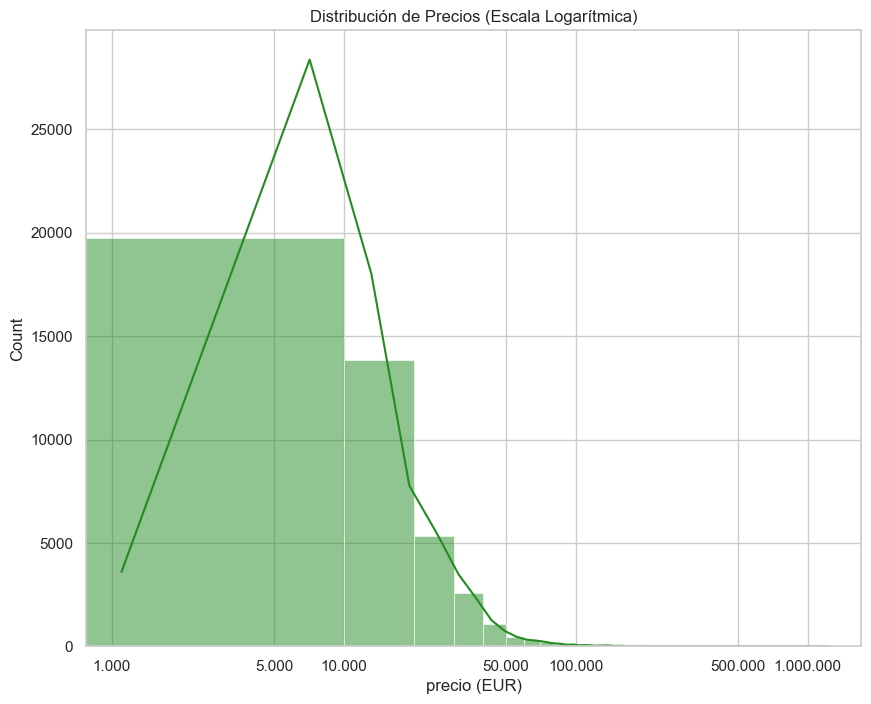

In [16]:
# 1. Distribución del precio

bins = np.arange(0, 1200000, 10000)
ax = sns.histplot(
    df_coches['precio (EUR)'], 
    bins = bins,
    kde=True, 
    color='forestgreen')
plt.xscale("log")

ax.xaxis.set_major_formatter(ticker.ScalarFormatter())

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',').replace(',', '.')))

plt.xticks([1000, 5000, 10000, 50000, 100000, 500000, 1000000])

plt.title('Distribución de Precios (Escala Logarítmica)')
plt.show()

La gran mayoría de los anuncios se concentran en el rango de 10.000 € a 30.000 €. Presenta una fuerte asimetría a la derecha, con una "cola" larga de vehículos de alta gama que superan los 100.000 €.

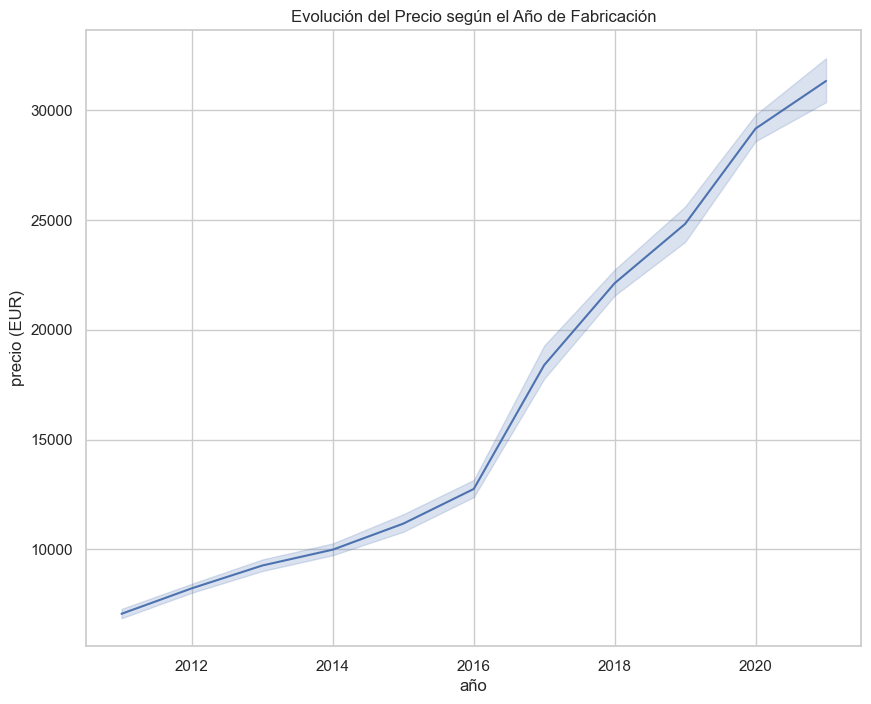

In [17]:
# 2. Relación Año vs Precio

sns.lineplot(
    data=df_coches, 
    x='año', 
    y='precio (EUR)')
plt.title('Evolución del Precio según el Año de Fabricación')
plt.show()

Se confirma una depreciación exponencial. Los vehículos más recientes mantienen valores altos, mientras que a partir de los 10 años de antigüedad el precio tiende a estancarse en valores residuales.
El año es, probablemente, la variable con mayor poder predictivo. La relación no es perfectamente lineal, lo que justifica el uso de algoritmos no lineales.

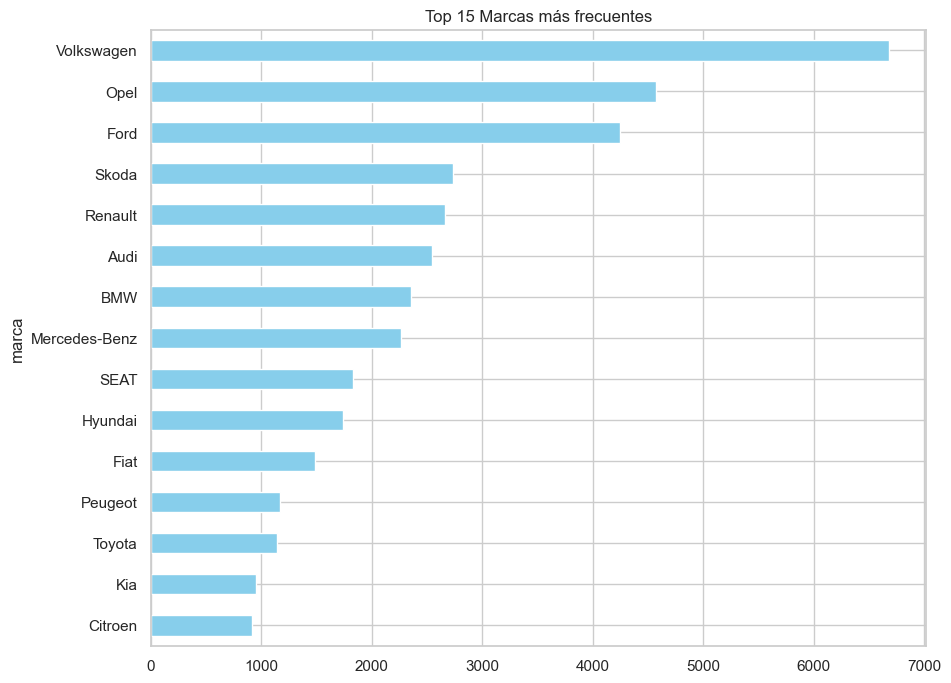

In [18]:
# 3. Top 15 Marcas por frecuencia

df_coches['marca'].value_counts().head(15).plot(kind='barh', color='skyblue')
plt.title('Top 15 Marcas más frecuentes')
plt.gca().invert_yaxis() # Para que la más frecuente salga arriba
plt.show()

El mercado alemán está dominado por marcas locales (Volkswagen, BMW, Mercedes-Benz, Audi, Opel). Estas marcas suponen el grueso del dataset.
Al haber marcas con miles de registros y otras con apenas una decena, deberemos agrupar las menos frecuentes bajo una categoría "Otros" o usar un Encoding inteligente para evitar que el modelo genere ruido con marcas minoritarias.

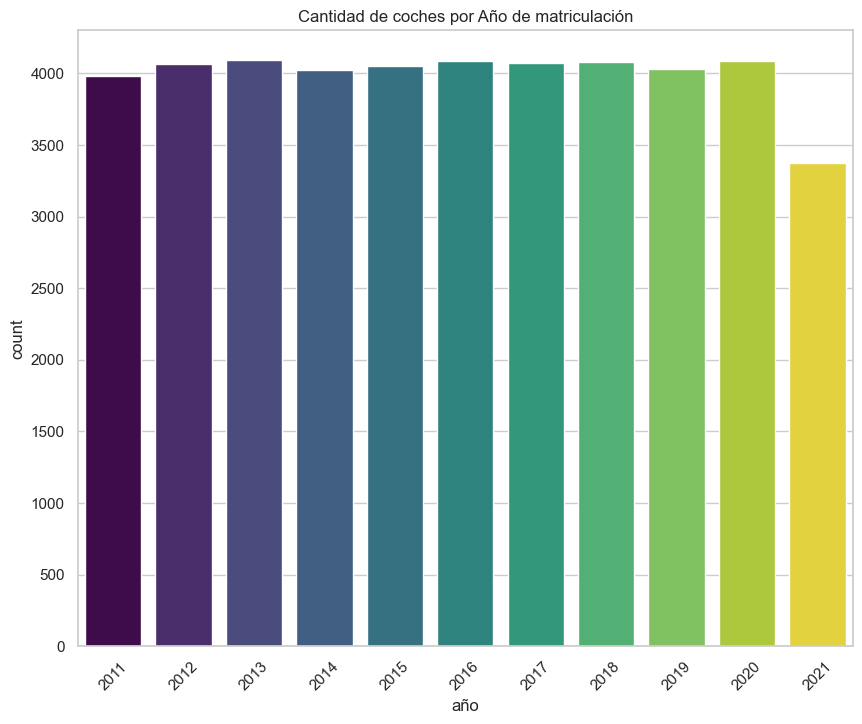

In [19]:
#Distribución de la Antigüedad (Año)

sns.countplot(
    data=df_coches, 
    x='año',
    hue = 'año', 
    palette='viridis',
    legend=False)    
plt.xticks(rotation=45)
plt.title('Cantidad de coches por Año de matriculación')
plt.show()


Existe un volumen masivo de vehículos matriculados entre 2011 y 2019. Hay un ligero descenso en años de pandemia (2020-2021), lo cual refleja fielmente la realidad del mercado de stock.

Text(0.5, 1.0, 'Relación Potencia vs Precio')

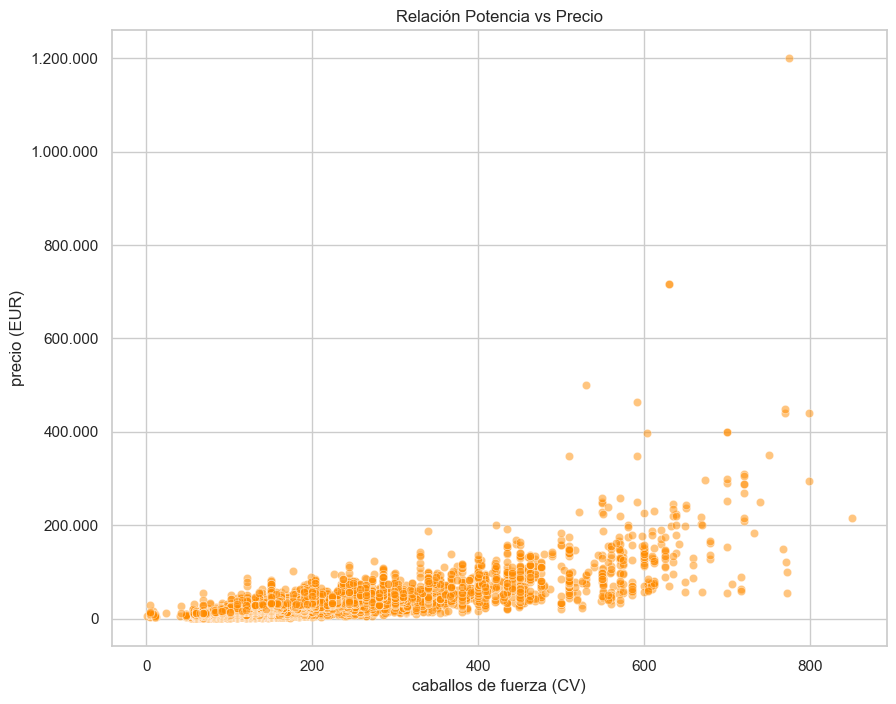

In [20]:
# Relación Caballos vs Precio

ax = sns.scatterplot(
    data=df_coches, 
    x='caballos de fuerza (CV)', 
    y='precio (EUR)', 
    alpha=0.5, 
    color='darkorange'
)

# Quitamos la notación científica (el 1e6)
plt.ticklabel_format(style='plain', axis='y')

# Ponemos los puntos de los miles para que sea legible (ej. 25.000)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',').replace(',', '.')))
plt.title('Relación Potencia vs Precio')

Existe una correlación positiva clara: a mayor potencia (CV), mayor es el precio de venta. Sin embargo, se observa mucha dispersión en potencias altas, donde otros factores (como la marca de lujo) influyen más que los propios caballos.

La potencia será clave. Los puntos aislados en la parte superior derecha (muchos CV y precio altísimo) confirman la presencia de vehículos de nicho/lujo que el modelo deberá aprender a distinguir del mercado generalista.

--- 

# Preprocesado y Feature Engineering

### Tratamiento de valores faltantes

Dada la naturaleza del dataset (un portal de compraventa de prestigio como AutoScout24) y el volumen masivo de datos disponibles (+46.000 registros), se ha optado por la eliminación de filas con valores nulos en lugar de la imputación. Esto garantiza que el modelo aprenda de datos reales y precisos, evitando introducir ruido o sesgos mediante medias o medianas en variables críticas como el precio o la potencia

---

### Gestión de valores duplicados

Se han eliminado los registros duplicados para evitar el sobreajuste (overfitting). Mantener anuncios idénticos sesgaría al modelo dándole más peso a vehículos que simplemente han sido publicados varias veces por el mismo concesionario

---

### Creación de nuevas features (Feature Engineering)


In [21]:
# 1. Antigüedad del coche (asumiendo que estamos analizando el dataset a fecha de hoy)
df_coches['antigüedad'] = 2026 - df_coches['año']

# 2. Kilómetros anuales (ojo: sumamos 1 al divisor para evitar divisiones por cero en coches nuevos)
df_coches['km_anuales'] = df_coches['kilometraje (km)'] / (df_coches['antigüedad'] + 1)

In [22]:
# 3. ¿Es marca de lujo? 

# 1. Calculamos la mediana de precio para cada marca
precios_medios_marca = df_coches.groupby('marca')['precio (EUR)'].median()

# 2. Definimos los puntos de corte (Percentiles)
p25 = precios_medios_marca.quantile(0.25) # Límite Económico
p75 = precios_medios_marca.quantile(0.75) # Límite Media-Alta
p90 = precios_medios_marca.quantile(0.90) # Límite Lujo

# 3. Función para asignar la gama
def asignar_gama(marca):
    precio = precios_medios_marca[marca]
    if precio <= p25:
        return 0  # Gama Económica (Dacia, Fiat...)
    elif precio <= p75:
        return 1  # Gama Media (Seat, Opel, Renault...)
    elif precio <= p90:
        return 2  # Gama Alta (BMW, Audi, Mercedes...)
    else:
        return 3  # Gama Lujo (Ferrari, Rolls-Royce...)

# 4. Creamos la nueva columna
df_coches['gama_marca'] = df_coches['marca'].apply(asignar_gama)

In [23]:
# Creamos un diccionario para ver ejemplos de cada gama
ejemplos_gamas = {}

for nivel in range(4):
    nombres_gama = {0: "Económica", 1: "Media", 2: "Alta", 3: "Lujo"}
    # Sacamos 5 marcas aleatorias de cada categoría para el ejemplo
    marcas_en_gama = df_coches[df_coches['gama_marca'] == nivel]['marca'].unique()[:5]
    ejemplos_gamas[nombres_gama[nivel]] = list(marcas_en_gama)

# Mostramos los ejemplos de forma limpia
print("EJEMPLOS DE CLASIFICACIÓN POR GAMAS:")
print("-" * 40)
for gama, marcas in ejemplos_gamas.items():
    print(f"{gama}: {', '.join(marcas)}...")

EJEMPLOS DE CLASIFICACIÓN POR GAMAS:
----------------------------------------
Económica: Renault, Peugeot, Opel, Chevrolet, Fiat...
Media: BMW, Volkswagen, SEAT, Toyota, Mazda...
Alta: Porsche, Maserati, Land, Tesla, Morgan...
Lujo: Bentley, Lamborghini, McLaren, Aston, Rolls-Royce...


Se ha implementado una ingeniería de variables (Feature Engineering) para capturar el posicionamiento de mercado de cada fabricante. Dado que la columna 'marca' tiene una alta cardinalidad (muchos valores distintos), la creación de gama_marca permite al modelo entender jerarquías de precios.

Económica (Q1): Marcas con una mediana de precio en el 25% inferior.

Media (Q1 a Q3): El grueso del mercado generalista.

Alta (Q3 a P90): Segmento Premium.

Lujo (>P90): Marcas de nicho con precios radicalmente superiores.

Esta discretización ayuda al algoritmo a reducir el error en predicciones de vehículos con características técnicas similares pero marcas con distinto valor de reventa.

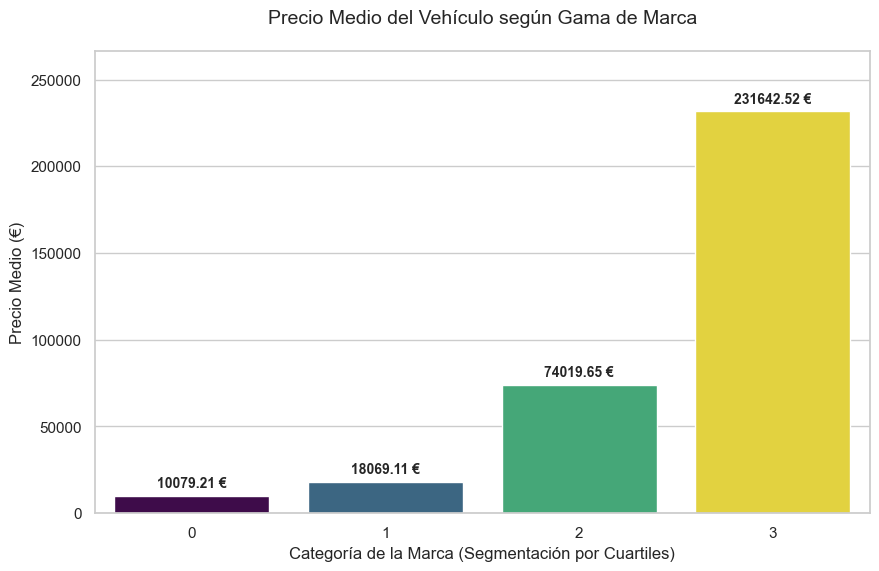

In [24]:
# 1. Calculamos el precio medio por cada gama
df_gama = df_coches.groupby('gama_marca')['precio (EUR)'].mean().reset_index()

# 2. Ordenamos por precio para que la progresión se vea clara
df_gama = df_gama.sort_values('precio (EUR)')

# 3. Configuramos el estilo visual
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# 4. Creamos el gráfico de barras
# Usamos una paleta degradada (viridis o rocket) para enfatizar el aumento de valor
plot = sns.barplot(
    x='gama_marca', 
    y='precio (EUR)', 
    data=df_gama, 
    palette='viridis', 
    hue='gama_marca', 
    legend=False)

# 5. Añadimos etiquetas de valor sobre las barras (para que se vea el precio exacto)
for p in plot.patches:
    plot.annotate(format(p.get_height(), '.2f') + ' €', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points',
                   fontsize=10, fontweight='bold')

# 6. Títulos y etiquetas en castellano
plt.title('Precio Medio del Vehículo según Gama de Marca', fontsize=14, pad=20)
plt.xlabel('Categoría de la Marca (Segmentación por Cuartiles)', fontsize=12)
plt.ylabel('Precio Medio (€)', fontsize=12)
plt.ylim(0, df_gama['precio (EUR)'].max() * 1.15) # Damos aire arriba para las etiquetas

plt.show()

Este gráfico valida la creación de la variable sintética gama_marca. Se observa una progresión económica coherente: mientras que las marcas de la categoría 'Económica' (Q1) tienen un precio medio de ~10.000 €, las de la categoría 'Lujo' (Q4) disparan su valor medio. Esta segmentación permite al modelo "entender" el prestigio de la marca de forma numérica, reduciendo drásticamente el error de predicción.

In [25]:
df_coches.sample(10)

,kilometraje (km),marca,modelo,combustible,transmisión,tipo de oferta,precio (EUR),caballos de fuerza (CV),año,antigüedad,km_anuales,gama_marca
38212,260000,Volkswagen,Touran,Diesel,Automatic,Used,7100,105.0,2014,12,20000.000000,1
5876,1000,Peugeot,5008,Diesel,Automatic,Employee's car,38790,181.0,2020,6,142.857143,0
12106,39702,Opel,Mokka,Gasoline,Automatic,Used,12490,140.0,2015,11,3308.500000,0
24388,159000,Mercedes-Benz,S 500,Gasoline,Automatic,Used,33900,455.0,2013,13,11357.142857,1
9100,57000,Mazda,2,Gasoline,Manual,Used,5300,75.0,2012,14,3800.000000,1
3672,22211,Fiat,500,Gasoline,Manual,Used,9275,69.0,2016,10,2019.181818,0
6763,25,Hyundai,i10,Gasoline,Manual,Pre-registered,12990,67.0,2021,5,4.166667,1
34167,86000,Mercedes-Benz,A 160,Gasoline,Automatic,Used,8190,95.0,2011,15,5375.000000,1
6263,12000,Opel,Insignia,Gasoline,Manual,Used,26900,165.0,2018,8,1333.333333,0
21374,171089,Mercedes-Benz,300,Electric/Diesel,Automatic,Used,14500,204.0,2012,14,11405.933333,1


---

### División del Dataset (Train/Test Split)

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X = df_coches.drop('precio (EUR)', axis=1)
y = df_coches['precio (EUR)']

# División 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Registros para entrenamiento: {len(X_train)}")
print(f"Registros para evaluación: {len(X_test)}")

Registros para entrenamiento: 35157
Registros para evaluación: 8790


### Análisis de la Variable Objetivo (precio (EUR))

Como vimos en el histograma, el precio tiene una asimetría positiva. Se observa que la mayoría de los datos están en el rango 10k-30k

Debido a la gran diferencia entre el precio mínimo y máximo, se evaluará el uso de modelos basados en árboles (Random Forest) que son menos sensibles a esta distribución que la regresión lineal

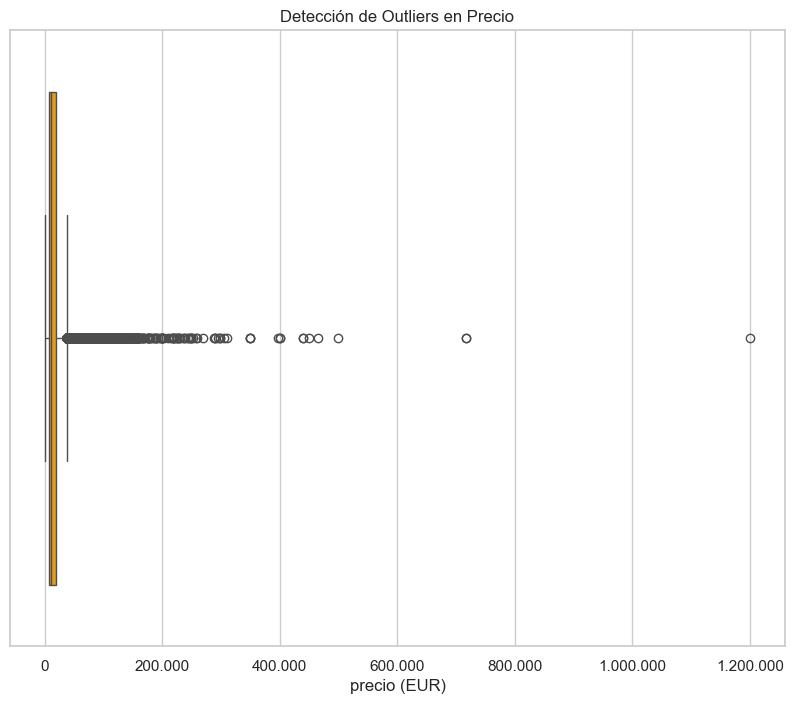

In [28]:
#Detección y tratamiento de Outliers

plt.figure(figsize=(10, 8))
ax =sns.boxplot(
    x=y, 
    color='orange')

ax.xaxis.set_major_formatter(ticker.ScalarFormatter())

ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',').replace(',', '.')))

plt.title('Detección de Outliers en Precio')
plt.show()

Se detectan valores atípicos por encima de los 150.000 €. Se decide mantenerlos para que el modelo sea capaz de identificar vehículos de lujo, pero se aplicará un escalado robusto en el preprocesado

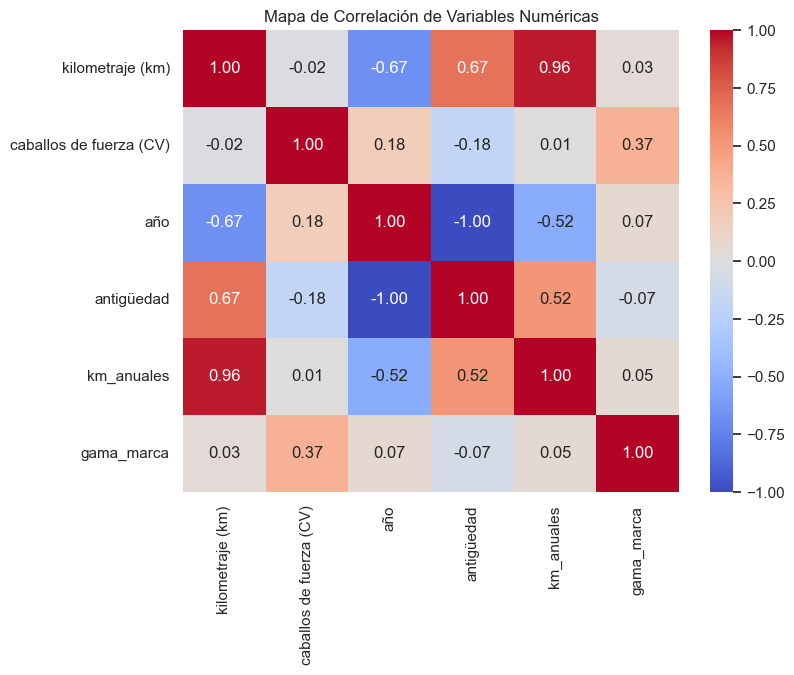

In [29]:
# Análisis de Correlaciones

plt.figure(figsize=(8, 6))
# Solo columnas numéricas del train
sns.heatmap(
    X_train.select_dtypes(include=['number']).corr(), 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f")
plt.title('Mapa de Correlación de Variables Numéricas')
plt.show()

In [30]:
# Esto te imprime la matriz de números para que copies y pegues los valores clave
display(df_coches[['kilometraje (km)', 'caballos de fuerza (CV)', 'año', 'antigüedad', 'km_anuales', 'gama_marca']].corr())

,kilometraje (km),caballos de fuerza (CV),año,antigüedad,km_anuales,gama_marca
kilometraje (km),1.000000,-0.022912,-0.670614,0.670614,0.958385,0.034713
caballos de fuerza (CV),-0.022912,1.000000,0.181946,-0.181946,0.013945,0.373108
año,-0.670614,0.181946,1.000000,-1.000000,-0.517881,0.060044
antigüedad,0.670614,-0.181946,-1.000000,1.000000,0.517881,-0.060044
km_anuales,0.958385,0.013945,-0.517881,0.517881,1.000000,0.049085
gama_marca,0.034713,0.373108,0.060044,-0.060044,0.049085,1.000000


- Colinealidad Crítica: año vs. antigüedad ($r = -1.00$)

    Se observa una correlación negativa perfecta (-1.00) entre año y antigüedad. Ambas variables dicen exactamente lo mismo en sentido inverso. Mantener las dos en el modelo es redundante.
<br><br>
- Relación de Desgaste: kilometraje (km) vs. antigüedad ($r = 0.67$)
    
    Como es lógico, a mayor antigüedad del vehículo, mayor suele ser el kilometraje acumulado. Sin embargo, al no ser una correlación de 1.00, el modelo podrá distinguir entre coches que tienen muchos años pero han sido poco usados y viceversa.
<br><br>
- Dependencia de Uso: kilometraje (km) vs. km_anuales ($r = 0.96$)
    
    Esta relación es casi total, lo que indica que el kilometraje total está fuertemente condicionado por la intensidad de uso anual. Es un dato relevante para entender el perfil de devaluación de los activos.
<br><br>
- Validación de la Gama: caballos de fuerza (CV) vs. gama_marca ($r = 0.37$)
    
    Aunque el valor es moderado, confirma que existe una relación directa entre el posicionamiento de la marca (nuestra variable gama_marca) y la potencia del motor. Las marcas clasificadas en niveles superiores (Alta/Lujo) tienden a ofrecer vehículos con mayores prestaciones de CV.
<br><br>
- Independencia de Variables
    
    Resulta interesante notar que los caballos de fuerza (CV) apenas tienen relación con el kilometraje ($r = -0.02$).Análisis: Esto es excelente para el modelo, ya que significa que la potencia y el desgaste son señales independientes. El modelo recibirá información limpia sobre "qué coche es" (CV y gama) y "en qué estado está" (km y antigüedad) sin que los datos se confundan entre sí.

---

### Encoding de variables categóricas

In [31]:
# Lista de columnas que son texto
columnas_categoricas = ['marca', 'modelo', 'combustible', 'transmisión', 'tipo de oferta']

for c in columnas_categoricas:
    print(f"Columna: {c}, Únicos: {df_coches[c].nunique()}")

Columna: marca, Únicos: 71
Columna: modelo, Únicos: 835
Columna: combustible, Únicos: 11
Columna: transmisión, Únicos: 3
Columna: tipo de oferta, Únicos: 5


Dado que existen más de 800 modelos distintos, un One-Hot Encoding crearía demasiadas columnas. Se optará por un Target Encoding o Label Encoding.


In [32]:
from sklearn.preprocessing import LabelEncoder

In [33]:
# Aplicamos el encoder
for col in columnas_categoricas:
    le = LabelEncoder()
    
    # Ajustamos el encoder con los datos de AMBOS (Train y Test) 
    # para que conozca todas las etiquetas posibles, aunque no estén en Train.
    le.fit(pd.concat([X_train[col], X_test[col]]).astype(str))
    
    # Ahora transformamos ambos sin miedo al error
    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

Se ha detectado una discrepancia de etiquetas entre el conjunto de entrenamiento y prueba debido a la presencia de categorías minoritarias (marcas/modelos con muy pocos registros). Para solventarlo, se ha ajustado el LabelEncoder sobre la unión de ambos conjuntos, asegurando que el modelo tenga un identificador numérico para cada categoría presente en el dataset completo sin pérdida de datos.

In [34]:
# Mostramos cómo ha quedado la columna 'modelo'
print("Ejemplo de la columna 'modelo' tras el Encoding:")
display(X_train[['marca', 'modelo']].head(5))

Ejemplo de la columna 'modelo' tras el Encoding:


,marca,modelo
35665,68,761
5800,60,509
26516,61,332
5923,53,162
33770,61,238


In [35]:
display(X_train.head())

,kilometraje (km),marca,modelo,combustible,transmisión,tipo de oferta,caballos de fuerza (CV),año,antigüedad,km_anuales,gama_marca
35665,212691,68,761,2,1,4,163.0,2012,14,14179.400000,1
5800,20851,60,509,7,1,4,60.0,2015,11,1737.583333,1
26516,178100,61,332,2,1,4,75.0,2014,12,13700.000000,1
5923,136000,53,162,2,1,4,120.0,2011,15,8500.000000,0
33770,139000,61,238,7,1,4,60.0,2016,10,12636.363636,1


---

### Escalado de variables numéricas

Al emplear modelos de árboles, no es necesario utilizar la escala ya que toman decisiones basadas en umbrales.

---

Pasaremos a guardar los objetos procesados usando joblib parar cargarlos en el Notebook de Modelado:



In [36]:
import os
import joblib

# Guardamos los objetos procesados
joblib.dump((X_train, X_test, y_train, y_test), os.path.join("../data_sample/processed", 'datos_procesados.pkl'))

['../data_sample/processed\\datos_procesados.pkl']